**Genetic with cross validation**

In [ ]:
from tabulate import tabulate

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import trange
from sklearn.preprocessing import MinMaxScaler
np.set_printoptions(suppress=True)


population_size = 50        # จำนวน individual
generations = 50        # จำนวน generation
feature_size = None        # จำนวน column / feature
class_size = None        # จำนวน class
crossover_prob = 0.8
mutation_prob = 0.01

# Cross validation

In [ ]:
def cross_validation(df):

    data = df
    last_column = df.columns[-1]

    # แยกข้อมูลตาม target class
    class_0_data = data[data[last_column] == 0.0]
    class_1_data = data[data[last_column] == 1.0]

    # ขนาด fold สำหรับแต่ละ class
    fold_size_class_0 = len(class_0_data) // 10 - 1
    fold_size_class_1 = len(class_1_data) // 10 - 1

    # เตรียม array สำหรับ train/test set ทั้ง 10 fold
    train_folds = np.empty(10, dtype='object')
    test_folds = np.empty(10, dtype='object')

    for fold_idx in range(1, 11):
        # index เริ่มและสิ้นสุดสำหรับแต่ละ class
        if fold_idx == 10:
            start_class_0 = (fold_idx - 1) * (fold_size_class_0 + 1)
            end_class_0 = len(class_0_data)

            start_class_1 = (fold_idx - 1) * (fold_size_class_1 + 1)
            end_class_1 = len(class_1_data)
        else:
            start_class_0 = (fold_idx - 1) * (fold_size_class_0 + 1)
            end_class_0 = start_class_0 + fold_size_class_0

            start_class_1 = (fold_idx - 1) * (fold_size_class_1 + 1)
            end_class_1 = start_class_1 + fold_size_class_1


        # สร้าง test set ของ fold นี้
        test_class_0 = class_0_data[start_class_0:end_class_0 + 1]
        test_class_1 = class_1_data[start_class_1:end_class_1 + 1]

        # สร้าง train set ของ fold นี้
        train_class_0 = class_0_data.drop(class_0_data.index[start_class_0:end_class_0 + 1])
        train_class_1 = class_1_data.drop(class_1_data.index[start_class_1:end_class_1 + 1])

        # รวม class 0 และ class 1 เข้าเป็น train/test ของ fold
        test_folds[fold_idx - 1] = pd.concat([test_class_0, test_class_1], ignore_index=True).to_numpy()
        train_folds[fold_idx - 1] = pd.concat([train_class_0, train_class_1], ignore_index=True).to_numpy()

    return train_folds, test_folds


# Initial Population

In [ ]:
def initial_population(population_size):

    population = np.empty(population_size , dtype='object')

    for i in range(population_size):
        population[i] =  np.random.rand(class_size,feature_size)

    return population

# Evaluate Fitness

In [ ]:
def evaluate(populations, data_train):
    X = data_train[:, :-1]
    y = data_train[:, -1:]
    performance = []

    for pop_idx, population in enumerate(populations):
        count = 0
        for i in range(len(X)):
            data_clone = np.tile(X[i], (class_size,1))
            distance = np.sqrt(np.sum((population - data_clone)**2, axis=1))
            predict = np.argmin(distance)
            if y[i] == predict:
                count += 1
        performance.append((pop_idx, count))
    return np.array(performance)

# Rouletter Wheel Selection

In [ ]:
def roulette_wheel_selection(performance):
    total_fitness = np.sum(performance[:,1])
    probabilities = performance[:,1] / total_fitness
    ranges = []

    start = 0
    for p in probabilities:
        finish = start + p
        ranges.append((start, finish))
        start = finish
    return np.array(ranges)

In [ ]:
def select_population(roulette_ranges, populations):
    num_pairs = len(roulette_ranges)//2
    parents = np.empty((num_pairs, 2), dtype='object')

    for idx in range(num_pairs):
        father_rand = np.random.uniform(0,1)
        mother_rand = np.random.uniform(0,1)

        # Father
        for i, (start, finish) in enumerate(roulette_ranges):
            if start <= father_rand and father_rand < finish:
                parents[idx, 0] = populations[i]

        # Mother
        for i, (start, finish) in enumerate(roulette_ranges):
            if start <= mother_rand and mother_rand  < finish:
                parents[idx, 1] = populations[i]

    return parents

# Cross Over

In [ ]:
# Single-point crossover

def cross_over(parents):
    num_pairs = len(parents)
    children1 = np.empty(num_pairs, dtype=object)
    children2 = np.empty(num_pairs, dtype=object)

    for index in range(num_pairs):
        father = parents[index, 0]
        mother = parents[index, 1]

        # random single-point crossover
        cross_points = np.random.permutation(np.arange(1, feature_size))
        cross_point = cross_points[0] # เอาตำแหน่งแรกเป็นจุด Crossover

        if np.random.uniform(0, 1) <= crossover_prob:
            # แบ่ง gene และสลับ
            # axis=0 → rows
            # axis=1 → column
            child1 = np.concatenate((father[:, 0:cross_point], mother[:, cross_point:]), axis=1)
            child2 = np.concatenate((mother[:, 0:cross_point], father[:, cross_point:]), axis=1)
        else:
            # ไม่มี crossover
            child1 = father
            child2 = mother

        children1[index] = child1
        children2[index] = child2

    # รวมลูกทั้งหมด
    return np.concatenate((children1, children2))




# Mutation

In [ ]:
def mutation(children):
    for idx in range(len(children)):
        chromosome = children[idx]
        for gene_idx in range(feature_size):
            if np.random.random() <= mutation_prob:
                chromosome[:, gene_idx] += np.random.uniform(-0.1, 0.1)
                chromosome[:, gene_idx] = np.clip(chromosome[:, gene_idx], 0, 1)
        children[idx] = chromosome
    return children

# Sort function

In [ ]:
def sort_after_combined(performance_combined):
    sort_idx = np.argsort(performance_combined[:,1])[::-1]
    sorted_top = performance_combined[sort_idx][:population_size]
    top_idx = sorted_top[:,0].astype(int)
    top_performance = sorted_top[:,1]

    return top_idx, top_performance

# Evaluate Model

In [ ]:
def evaluate_model(model , data_test):
    X = data_test[:,:feature_size]
    y = data_test[:,-1:]

    count = 0

    for index in range(len(X)):

        data_clone = np.tile(X[index], (class_size,1))
        distance = np.sqrt(np.sum((model - data_clone)**2 ,axis=1))
        predict = np.argmin(distance)

        if predict ==  y[index]:
            count = count+1


    return count

# Plot Graph

In [76]:

def plot_performance(histories, accuracies, header=""):
    total_plots = len(histories)
    rows, cols = 2, 5  # 2 แถว 5 คอลัมน์

    # สร้าง subplots
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4), sharey=True)

    # แปลง axes เป็น 1D array เพื่อ loop ง่ายขึ้น
    axes = axes.flatten()

    for i in range(total_plots):
        ax = axes[i]
        history = histories[i]
        accuracy = accuracies[i]

        # วาดเส้นกราฟ
        ax.plot(range(1, len(history) + 1), history, marker='o', linestyle='-', linewidth=1, markersize=2)

        # Title & labels ของแต่ละ subplot
        ax.set_xlabel("Iteration", fontsize=10)
        ax.set_ylabel("Performance", fontsize=10)

        # Grid
        ax.grid(True, linestyle="--", alpha=0.6)
        ax.tick_params(labelleft=True)

        # แสดง Accuracy ขวาล่าง (axes coordinates)
        ax.text(0.95, 0.05, f"Acc = {accuracy:.4f}",
                fontsize=9, color="blue",
                ha="right", va="bottom",
                transform=ax.transAxes,  # ใช้พิกัด axes 0–1
                bbox=dict(facecolor="white", alpha=0.3, edgecolor="blue"))

    # ซ่อน axes ที่ไม่ได้ใช้ (กรณีมีกราฟน้อยกว่า 10)
    for j in range(total_plots, len(axes)):
        fig.delaxes(axes[j])

    # เพิ่ม title ใหญ่ของทั้ง Figure
    fig.suptitle(header, fontsize=16, fontweight='bold')

    plt.tight_layout(rect=[0, 0, 1, 0.96])  # เว้นพื้นที่ให้ suptitle
    plt.show()


# Genetic Flow

In [ ]:
def genetic_flow(populations, train_data):
    performance_record = []

    for _ in trange(generations):
        fitness = evaluate(populations, train_data)
        roulette_ranges = roulette_wheel_selection(fitness)
        parents = select_population(roulette_ranges, populations)
        children = cross_over(parents)
        mutated_children = mutation(children)

        combined_population = np.concatenate((populations, mutated_children))
        combined_fitness = evaluate(combined_population, train_data)

        top_idx, top_perf = sort_after_combined(combined_fitness)
        populations = combined_population[top_idx]


        performance_record.append(top_perf[0])

    model = populations[0]
    return model, performance_record

# Main

In [72]:
def main():
   global feature_size, class_size
   df = pd.read_excel('/content/cervical_cancer_balanced.xlsx')
   class_size = df.iloc[:, -1].nunique()
   feature_size = df.shape[1]-1
   train , test = cross_validation(df)
   history = []
   final_accuracy_test = []
   final_accuracy_train = []
   accuracy_comparison = []

   for i in range(len(train)):
        populations = initial_population(population_size)
        model, performance =genetic_flow(populations, train[i])
        acc_test = evaluate_model(model , test[i])
        acc_train = evaluate_model(model , train[i])



        history.append(performance)
        final_acc_test = acc_test / len(test[i])
        final_acc_train = acc_train / len(train[i])
        final_accuracy_test.append(final_acc_test)
        final_accuracy_train.append(final_acc_train)
        accuracy_comparison.append([len(test[i]), final_acc_test, final_acc_test])


   return history, final_accuracy_train , accuracy_comparison




In [74]:
if __name__ == "__main__":
  history, final_accuracy, accuracy_comparison = main()

100%|██████████| 50/50 [00:15<00:00,  3.31it/s]


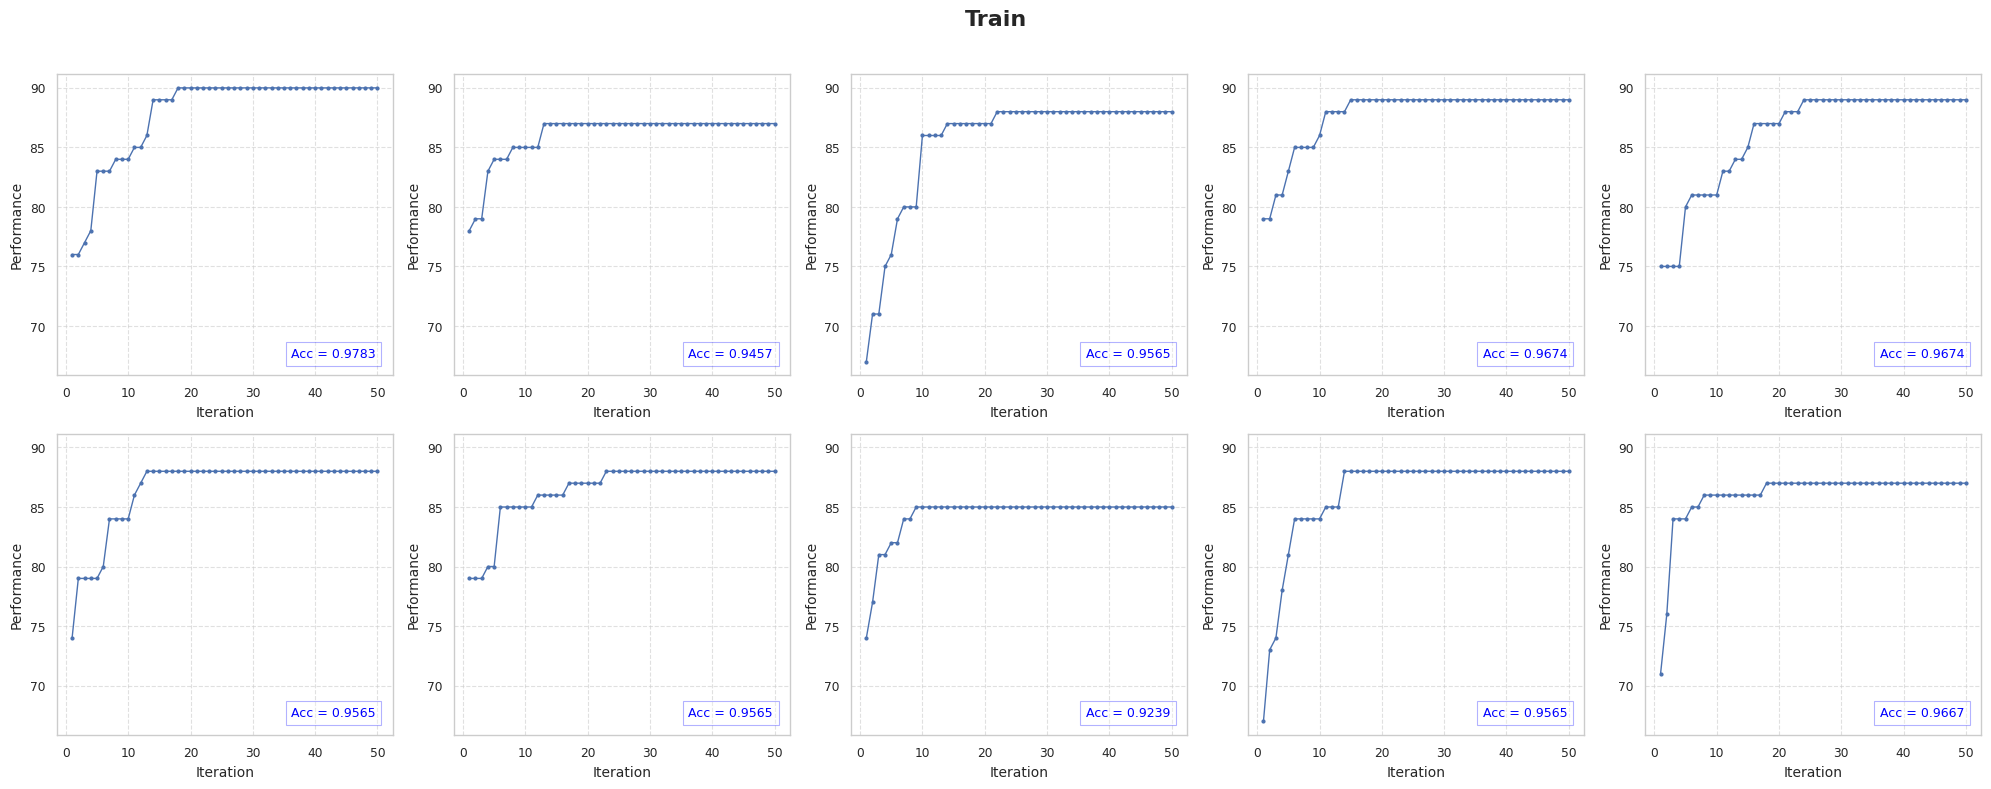

In [78]:
plot_performance(history , final_accuracy, header="Train")

In [ ]:

accuracy_array = np.array(accuracy_comparison)
df_accuracy = pd.DataFrame(accuracy_array, columns=["test_size", "correct_predict", "accuracy"])

# คำนวณ average และ std
avg_values = df_accuracy['accuracy'].mean()
std_values = df_accuracy['accuracy'].std()

print(tabulate(df_accuracy, headers='keys', tablefmt="github", showindex=False))
print('Average: ' , avg_values)
print('STD: ' , std_values)


|   test_size |   correct_predict |   accuracy |
|-------------|-------------------|------------|
|          10 |                10 |   1        |
|          10 |                 6 |   0.6      |
|          10 |                 9 |   0.9      |
|          10 |                 9 |   0.9      |
|          10 |                 9 |   0.9      |
|          10 |                10 |   1        |
|          10 |                10 |   1        |
|          10 |                10 |   1        |
|          10 |                10 |   1        |
|          12 |                11 |   0.916667 |
Average:  0.9216666666666666
STD:  0.12273880728936067
